# Project 01 (basic) — Convolution & filters by hand, and learned filters

**Module 11 — Computer Vision** · Format: **Jupyter notebook** (`convolution_filters.ipynb`)

Before a CNN learns anything, you have to understand the **convolution** — the operation
that underlies everything. In this notebook you implement the 2D convolution yourself, apply
classical, **hand-designed** filters (Gaussian, Sobel) to a real image and then build the
bridge to deep learning: you visualize the filters that a **pretrained ResNet** *learned* in
its first layer — and find that they are strikingly similar to the hand-designed edge/color
detectors.

Core questions:
- How does a convolution compute a feature map from an image + kernel?
- How do **Sobel** filters find edges (gradient magnitude)?
- What do the first filters *learned* by a network look like — and why is that the proof
  that "learning filters" works?

> **Plenty of instruction, no training.** Everything runs in seconds on the CPU.


## Setup

Requires `numpy`, `matplotlib`, `torch`, `torchvision` (all in the repo `requirements.txt`).
The example image (*Grace Hopper*) is included in matplotlib — no download needed. The
pretrained ResNet18 (~45 MB) is loaded once on the first run and cached.

```bash
source ../../../../.venv/bin/activate
jupyter lab      # or open convolution_filters.ipynb in VS Code, kernel = repo .venv
```


## Part A — Load the image *(given)*

An image is a grid of numbers. We load a real photo, convert it to **grayscale** (a matrix
$H\times W$ with values in $[0,1]$) and display it.


Color image: (600, 512, 3)  grayscale: (600, 512)  value range: 0.0 - 1.0


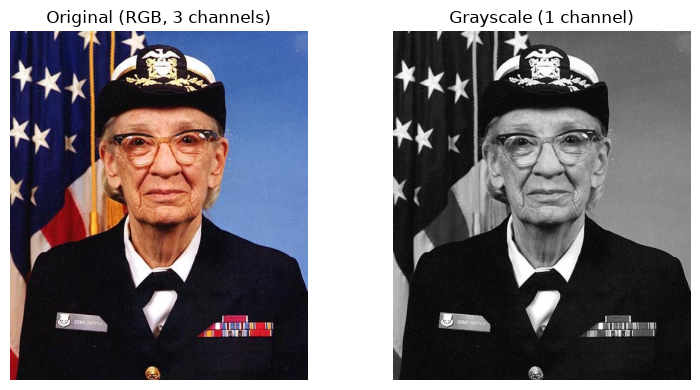

In [1]:
# ---- Load the image & convert to grayscale (given) ------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from PIL import Image

with cbook.get_sample_data("grace_hopper.jpg") as f:
    img_rgb = np.asarray(Image.open(f).convert("RGB")).astype(np.float32) / 255.0

# grayscale via luminance weighting (ITU-R 601)
gray = img_rgb @ np.array([0.299, 0.587, 0.114], dtype=np.float32)
print("Color image:", img_rgb.shape, " grayscale:", gray.shape, " value range:",
      round(float(gray.min()), 2), "-", round(float(gray.max()), 2))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_rgb); ax[0].set_title("Original (RGB, 3 channels)"); ax[0].axis("off")
ax[1].imshow(gray, cmap="gray"); ax[1].set_title("Grayscale (1 channel)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

### Task 1 — 2D convolution by hand

Implement `convolve2d(image, kernel)` with **zero padding** ("same": output as large as the
input). For a $k\times k$ kernel $K$ and image $I$:
$$(I*K)(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1} I_{\text{pad}}(i+u,\,j+v)\,K(u,v).$$

**Efficiency tip (`# TODO`):** instead of looping over every output pixel, loop over the
**$k\times k$ kernel positions** and accumulate the appropriately **shifted** image region
each time — this is fully vectorized and fast:

```
out = 0
for u in range(k):
    for v in range(k):
        out += K[u,v] * padded[u : u+H, v : v+W]
```


In [2]:
# ---- TASK 1: 2D convolution ----------------------------------------------
def convolve2d(image, kernel):
    """Convolution (cross-correlation) with zero padding, output size = input size."""
    k = kernel.shape[0]
    p = k // 2
    H, W = image.shape
    padded = np.pad(image, p, mode="constant")
    out = np.zeros((H, W), dtype=np.float32)
    for u in range(k):
        for v in range(k):
            out += kernel[u, v] * padded[u:u + H, v:v + W]
    return out

# Test: the identity kernel returns the image; box blur smooths
identity = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.float32)
assert np.allclose(convolve2d(gray, identity), gray, atol=1e-5)
box = np.ones((3, 3), dtype=np.float32) / 9.0
blur = convolve2d(gray, box)
print("Identity test passed. Box blur computed:", blur.shape)

Identity test passed. Box blur computed: (600, 512)


### Task 2 — Classical filters & edge detection

Apply hand-designed kernels. The Gaussian (smoothing) and sharpening are given. For the
**edges** you need the **Sobel** filters and the **gradient magnitude**:
$$K_x=\begin{pmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{pmatrix},\quad
K_y=\begin{pmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{pmatrix},\quad
G=\sqrt{G_x^2+G_y^2}.$$

**Your task (`# TODO`):** compute $G_x=I*K_x$, $G_y=I*K_y$ and the gradient magnitude $G$.


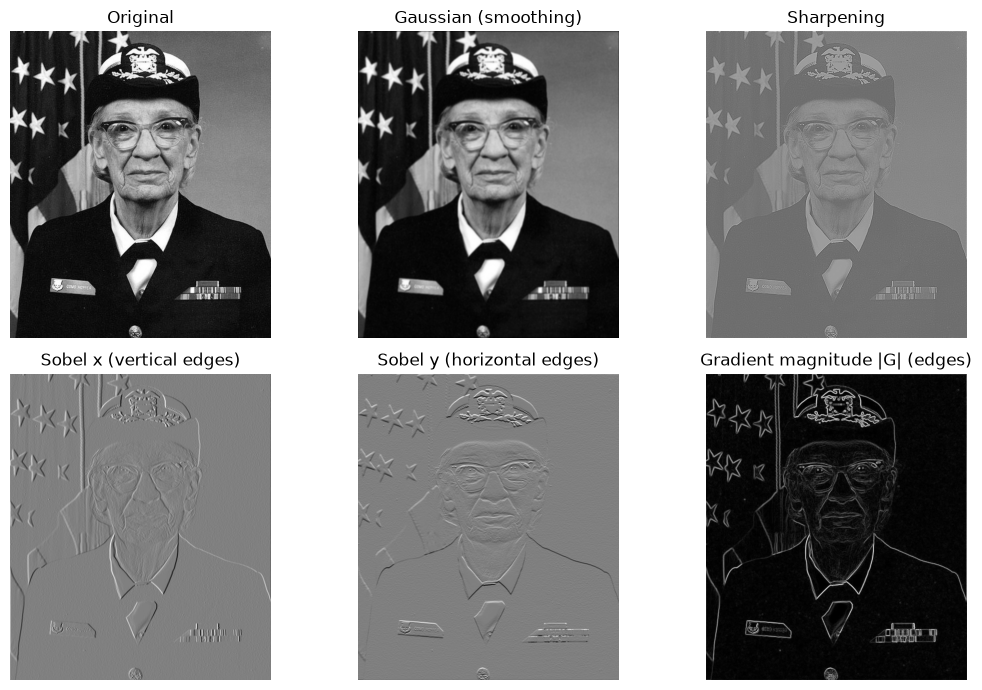

Sobel gradient magnitude: min 0.0 max 4.06


In [3]:
# ---- TASK 2: Sobel edges + given filters ---------------------------------
# Gaussian kernel (5x5) and sharpening (given)
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (g / g.sum()).astype(np.float32)

sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

gauss = convolve2d(gray, gaussian_kernel(5, 1.2))
sharp = convolve2d(gray, sharpen)
Gx = convolve2d(gray, Kx)
Gy = convolve2d(gray, Ky)
G = np.sqrt(Gx**2 + Gy**2)

fig, ax = plt.subplots(2, 3, figsize=(11, 7))
for a, im, t in zip(ax.ravel(),
                    [gray, gauss, sharp, Gx, Gy, G],
                    ["Original", "Gaussian (smoothing)", "Sharpening",
                     "Sobel x (vertical edges)", "Sobel y (horizontal edges)",
                     "Gradient magnitude |G| (edges)"]):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()
print("Sobel gradient magnitude: min", round(float(G.min()),2), "max", round(float(G.max()),2))

### Task 3 — *Learned* filters of a pretrained network

Now the bridge to deep learning: a CNN does not **design** its filters, it **learns** them
from data. We load a **pretrained ResNet18** and look at its very first convolution layer —
64 filters of shape $3\times7\times7$ (RGB). Visualizing them shows **edge and color
detectors** — exactly the kind of filter you built by hand above, only learned from 1.2
million ImageNet images.

**Your task (`# TODO`):** send the (preprocessed) image through `conv1` and visualize a few
of the resulting **feature maps**.


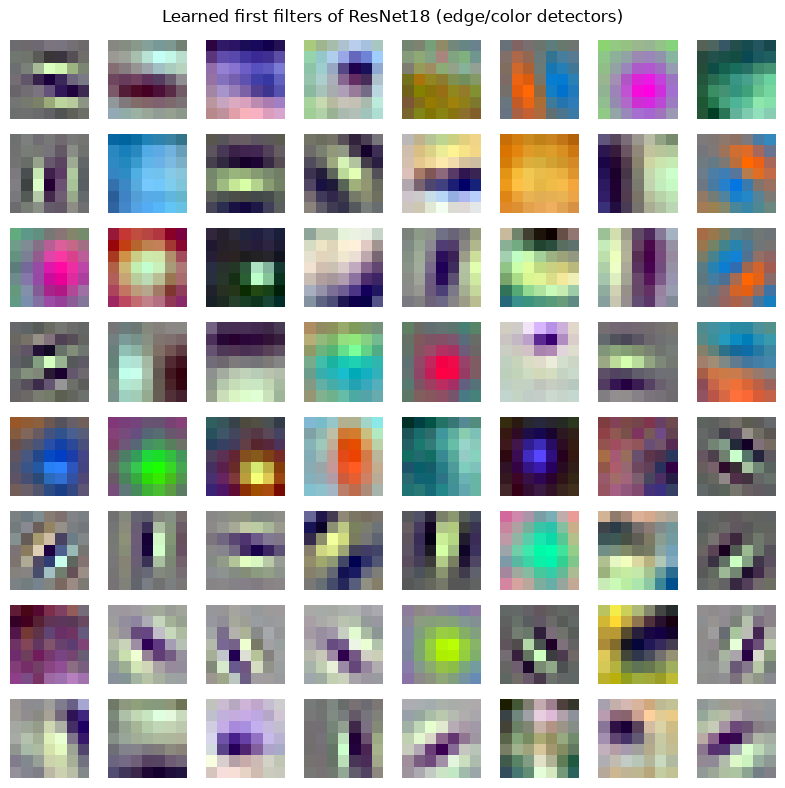

Feature map tensor: (1, 64, 112, 112)


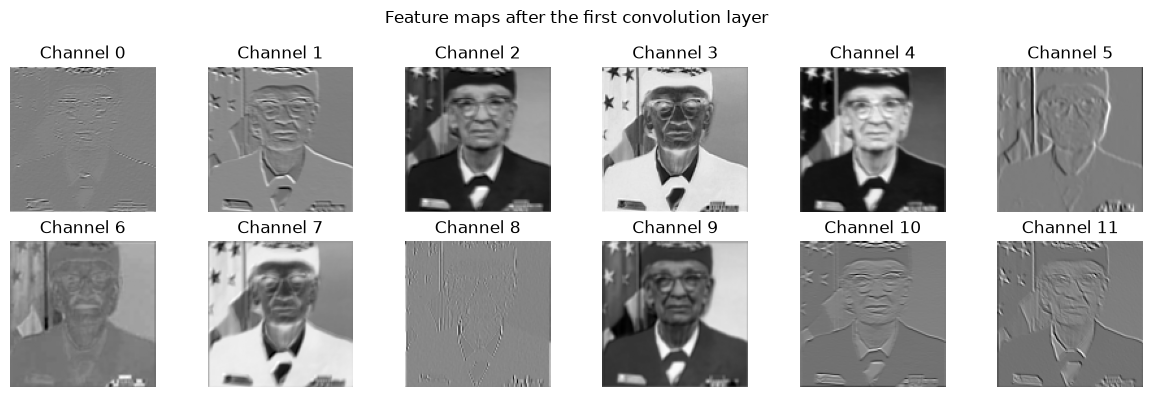

In [4]:
# ---- TASK 3: learned first filters + feature maps ------------------------
import torch
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights).eval()

# (a) the 64 learned conv1 filters (3x7x7) as small RGB images (given)
filters = model.conv1.weight.detach().numpy()          # (64, 3, 7, 7)
def norm01(a):
    return (a - a.min()) / (a.max() - a.min() + 1e-8)
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, a in enumerate(axes.ravel()):
    a.imshow(norm01(filters[i].transpose(1, 2, 0))); a.axis("off")
fig.suptitle("Learned first filters of ResNet18 (edge/color detectors)")
plt.tight_layout(); plt.show()

# (b) send the image through conv1 and show the feature maps
preprocess = weights.transforms()
x = preprocess(Image.fromarray((img_rgb * 255).astype(np.uint8))).unsqueeze(0)  # (1,3,224,224)
with torch.no_grad():
    feats = model.conv1(x)

print("Feature map tensor:", tuple(feats.shape))
fmaps = feats[0].detach().numpy()
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, a in enumerate(axes.ravel()):
    a.imshow(fmaps[i], cmap="gray"); a.set_title(f"Channel {i}"); a.axis("off")
fig.suptitle("Feature maps after the first convolution layer")
plt.tight_layout(); plt.show()

## Reflection — reference answers

1. **Convolution.** The Sobel-x kernel has negative weights on the left column and positive
   weights on the right (with a doubled center row). At a vertical edge — dark on the left,
   bright on the right — the positive side lands on the bright pixels and the negative side on
   the dark ones, so the weighted sum is large in magnitude. In a homogeneous area every pixel
   is (approximately) equal, and because the kernel weights sum to zero, the positive and
   negative contributions cancel → a response of ~0. The filter therefore responds to the
   *change* of brightness in the x direction, i.e. to vertical edges, not to the absolute
   brightness.

2. **Padding.** Without padding a $k\times k$ convolution removes $\lfloor k/2\rfloor$
   pixels at each border, so the output shrinks by $k-1$ in each dimension; stacking many
   layers would quickly shrink the image away. "Same" padding (surround the image with a
   border of zeros) keeps the output the same size as the input, which lets you stack layers
   freely, keep spatial correspondence between input and output, and treat the border pixels
   uniformly.

3. **Hand vs. learned.** The ResNet `conv1` filters look like oriented edge detectors and
   color-opponent blobs — visually the same family as the Sobel/Gaussian kernels you wrote by
   hand. The central insight is that a CNN does not need us to *design* these filters: given
   enough labelled data, gradient descent *learns* them on its own, because such low-level
   edge/color detectors are the most useful first-layer features for almost any image task.
   Hand-designed feature engineering (Sobel, SIFT, HOG) is replaced by *learned* features.

4. **Hierarchy.** Deeper layers combine the first-layer edges/colors into increasingly
   abstract features: textures and simple shapes in the middle, object parts and whole objects
   near the end. They are hard to visualize directly as a small RGB image because (i) their
   input has many channels (e.g. 64, 128, 256), so a single filter is a `(C_in, k, k)` tensor
   with no natural color interpretation, and (ii) what they detect is defined by the
   *composition* of all preceding layers, not by the raw weights alone — which is why one uses
   indirect methods (activation maximization, feature visualization, saliency) to inspect them.

> **Reference:** the gradient magnitude clearly traces the contours (face, uniform); the 64
> learned conv1 filters show oriented edges and color blobs — the "ImageNet version" of your
> Sobel/Gaussian kernels.
